# APS1 — Análise Exploratória dos Anúncios do Airbnb em Nova York

**Integrante:** Djairo Dantas da Silva Filho  
**Disciplina/turma:** Machine Learning — 4º semestre  
**Data de entrega:** 14/09/2026  
**Dataset:** [New York City Airbnb Open Data — Kaggle](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (`AB_NYC_2019.csv`)

## Objetivo

Investigar como localização, tipo de acomodação, disponibilidade e
atividade de avaliações se relacionam com o preço anunciado de uma
diária do Airbnb em Nova York em 2019. A análise prepara os dados para
uma futura tarefa de regressão cujo target será `price`.

O conjunto contém anúncios, não reservas concluídas. Portanto, as
conclusões dizem respeito a preços anunciados e não a receita, demanda
ou ocupação efetiva.

## Como ler este EDA

O notebook pode ser entendido como uma investigação em sete perguntas:

1. **O que cada linha representa?** Um anúncio, não uma reserva.
2. **O que queremos explicar?** O preço anunciado por noite.
3. **Os dados são utilizáveis?** Verificamos tipos, ausências e inconsistências.
4. **Como cada variável se comporta?** Usamos tabelas e análise univariada.
5. **Quais relações aparecem?** Comparamos variáveis e grupos no treino.
6. **Como preparar as features?** Criamos um pipeline sem vazamento.
7. **O que o resumo em duas dimensões mostra?** Usamos PCA com cautela.

Ao estudar, execute uma seção por vez e tente explicar cada saída com suas
próprias palavras antes de ler a interpretação escrita.

## 1. Configuração e reprodutibilidade

**O que queremos nesta etapa?** Preparar as bibliotecas e deixar explícitas as
escolhas que precisam permanecer iguais em futuras execuções.

A semente controla operações aleatórias, como a divisão treino–teste e as
amostras usadas nos gráficos. Assim, outra pessoa consegue reproduzir os mesmos
resultados.

In [1]:
from pathlib import Path
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

## 2. Carregamento e primeira leitura dos dados

**Pergunta da etapa:** estamos usando o arquivo esperado e ele possui a estrutura
descrita pela fonte?

O notebook procura primeiro o CSV local. Se ele não existir, baixa a versão
pública do Kaggle, o que também permite executar o trabalho no Colab. Depois,
validamos as colunas, mostramos as primeiras linhas, contamos valores únicos e
verificamos o período coberto por `last_review`.

In [2]:
current_dir = Path.cwd().resolve()
project_root = current_dir if (current_dir / "data").exists() else current_dir.parent
data_path = project_root / "data" / "raw" / "AB_NYC_2019.csv"

if not data_path.exists():
    import kagglehub
    dataset_dir = Path(
        kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
    )
    data_path = dataset_dir / "AB_NYC_2019.csv"

df = pd.read_csv(data_path)
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

expected_columns = {
    "id", "name", "host_id", "host_name", "neighbourhood_group",
    "neighbourhood", "latitude", "longitude", "room_type", "price",
    "minimum_nights", "number_of_reviews", "last_review",
    "reviews_per_month", "calculated_host_listings_count", "availability_365",
}
assert set(df.columns) == expected_columns, "O schema do CSV mudou."
assert not df.empty, "O dataset está vazio."

print(f"Arquivo: {data_path.name}")
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
display(df.head())

categorical_columns = ["neighbourhood_group", "neighbourhood", "room_type"]
initial_profile = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_únicos": df.nunique(dropna=True),
})
display(initial_profile)

categorical_examples = pd.DataFrame({
    "valores_únicos": df[categorical_columns].nunique(),
    "exemplos": [
        ", ".join(map(str, df[column].dropna().unique()[:8]))
        for column in categorical_columns
    ],
}, index=categorical_columns)
display(categorical_examples)
print(
    "Intervalo de last_review:",
    df["last_review"].min().date(),
    "a",
    df["last_review"].max().date(),
)

Arquivo: AB_NYC_2019.csv
Dimensões: 48,895 linhas × 16 colunas


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


,tipo,valores_únicos
id,int64,48895
name,str,47905
host_id,int64,37457
host_name,str,11452
neighbourhood_group,str,5
neighbourhood,str,221
latitude,float64,19048
longitude,float64,14718
room_type,str,3
price,int64,674


,valores_únicos,exemplos
neighbourhood_group,5,"Brooklyn, Manhattan, Queens, Staten Island, Bronx"
neighbourhood,221,"Kensington, Midtown, Harlem, Clinton Hill, Eas..."
room_type,3,"Private room, Entire home/apt, Shared room"


Intervalo de last_review: 2011-03-28 a 2019-07-08


## 3. Dicionário das variáveis

Antes de calcular qualquer estatística, precisamos entender o que cada coluna
representa. Um número nem sempre é uma medida: IDs são armazenados como inteiros,
mas servem apenas como identificadores e não devem ser interpretados como
quantidades.

In [3]:
data_dictionary = pd.DataFrame(
    [
        ("id", "identificador", "Identificador único do anúncio"),
        ("name", "texto", "Título do anúncio"),
        ("host_id", "identificador", "Identificador do anfitrião"),
        ("host_name", "texto", "Nome do anfitrião"),
        ("neighbourhood_group", "categórica", "Borough de Nova York"),
        ("neighbourhood", "categórica", "Bairro do anúncio"),
        ("latitude", "numérica", "Latitude do anúncio"),
        ("longitude", "numérica", "Longitude do anúncio"),
        ("room_type", "categórica", "Tipo de acomodação"),
        ("price", "numérica — target", "Preço anunciado por noite em US$"),
        ("minimum_nights", "numérica discreta", "Mínimo de noites exigido"),
        ("number_of_reviews", "numérica discreta", "Total de avaliações"),
        ("last_review", "data", "Data da avaliação mais recente"),
        ("reviews_per_month", "numérica", "Média de avaliações por mês"),
        (
            "calculated_host_listings_count",
            "numérica discreta",
            "Quantidade de anúncios do anfitrião",
        ),
        (
            "availability_365",
            "numérica discreta",
            "Dias disponíveis nos próximos 365 dias",
        ),
    ],
    columns=["variável", "tipo conceitual", "significado"],
)
display(data_dictionary)

,variável,tipo conceitual,significado
0,id,identificador,Identificador único do anúncio
1,name,texto,Título do anúncio
2,host_id,identificador,Identificador do anfitrião
3,host_name,texto,Nome do anfitrião
4,neighbourhood_group,categórica,Borough de Nova York
5,neighbourhood,categórica,Bairro do anúncio
6,latitude,numérica,Latitude do anúncio
7,longitude,numérica,Longitude do anúncio
8,room_type,categórica,Tipo de acomodação
9,price,numérica — target,Preço anunciado por noite em US$


## 4. Estrutura e qualidade dos dados

**Pergunta da etapa:** existe algo nos dados que possa distorcer os gráficos ou o
futuro modelo?

Investigamos tipos, ausências, duplicatas, valores incompatíveis e categorias
escritas de formas diferentes. Primeiro medimos os problemas; só depois
decidimos o que corrigir.

In [4]:
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

missing_summary = (
    df.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "quantidade", "mean": "proporção"})
    .assign(percentual=lambda table: 100 * table["proporção"])
    .drop(columns="proporção")
    .sort_values("quantidade", ascending=False)
)
missing_summary["quantidade"] = missing_summary["quantidade"].astype(int)
display(missing_summary)

print(f"Duplicatas completas: {df.duplicated().sum():,}")
print(f"IDs duplicados: {df['id'].duplicated().sum():,}")

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  str           
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  str           
 4   neighbourhood_group             48895 non-null  str           
 5   neighbourhood                   48895 non-null  str           
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  str           
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  number_of_rev

,quantidade,percentual
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


Duplicatas completas: 0
IDs duplicados: 0


### Entendendo as ausências das avaliações

Uma ausência não significa automaticamente erro. Um anúncio sem nenhuma
avaliação naturalmente não possui data da última avaliação nem média mensal.
A verificação abaixo testa essa hipótese antes de qualquer preenchimento.

In [5]:
review_consistency = pd.Series(
    {
        "Sem avaliações e reviews_per_month ausente": (
            (df["number_of_reviews"] == 0)
            & df["reviews_per_month"].isna()
        ).sum(),
        "Com avaliações e reviews_per_month ausente": (
            (df["number_of_reviews"] > 0)
            & df["reviews_per_month"].isna()
        ).sum(),
        "Sem avaliações e last_review ausente": (
            (df["number_of_reviews"] == 0)
            & df["last_review"].isna()
        ).sum(),
        "Com avaliações e last_review ausente": (
            (df["number_of_reviews"] > 0)
            & df["last_review"].isna()
        ).sum(),
    },
    name="quantidade",
)
display(review_consistency.to_frame())

,quantidade
Sem avaliações e reviews_per_month ausente,10052
Com avaliações e reviews_per_month ausente,0
Sem avaliações e last_review ausente,10052
Com avaliações e last_review ausente,0


**Observação:** as ausências em `reviews_per_month` e `last_review`
coincidem com anúncios sem avaliações; não há casos ausentes entre anúncios que
já receberam avaliações.

**Interpretação:** essas ausências são estruturais e têm significado próprio.

**Decisão:** preencher `reviews_per_month` com zero apenas quando
`number_of_reviews == 0` e criar `has_reviews`. A data bruta ficará fora do
baseline.

**Cuidado:** zero avaliações mensais não significa baixa qualidade; significa
apenas que não há atividade de avaliações registrada.

In [6]:
quality_checks = pd.Series(
    {
        "price ausente": df["price"].isna().sum(),
        "price <= 0": (df["price"] <= 0).sum(),
        "minimum_nights > 365": (df["minimum_nights"] > 365).sum(),
        "availability_365 fora de [0, 365]": (
            ~df["availability_365"].between(0, 365)
        ).sum(),
        "latitude fora do intervalo observado de NYC": (
            ~df["latitude"].between(40.49, 40.92)
        ).sum(),
        "longitude fora do intervalo observado de NYC": (
            ~df["longitude"].between(-74.26, -73.70)
        ).sum(),
    },
    name="quantidade",
)
display(quality_checks.to_frame())

display(
    df[["price", "minimum_nights", "availability_365"]]
    .describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])
    .T
)

category_hygiene = []
for column in categorical_columns:
    values = df[column].dropna().astype(str)
    stripped = values.str.strip()
    normalized = stripped.str.casefold()
    category_hygiene.append({
        "variável": column,
        "com_espaços_externos": int((values != stripped).sum()),
        "categorias_originais": int(values.nunique()),
        "categorias_sem_espaços_e_caixa": int(normalized.nunique()),
    })
display(pd.DataFrame(category_hygiene).set_index("variável"))

,quantidade
price ausente,0
price <= 0,11
minimum_nights > 365,14
"availability_365 fora de [0, 365]",0
latitude fora do intervalo observado de NYC,0
longitude fora do intervalo observado de NYC,0


,count,mean,std,min,90%,95%,99%,99.5%,99.9%,max
price,48895.0,152.720687,240.154170,0.0,269.0,355.0,799.0,1000.0,3000.000,10000.0
minimum_nights,48895.0,7.029962,20.510550,1.0,28.0,30.0,45.0,90.0,354.636,1250.0
availability_365,48895.0,112.781327,131.622289,0.0,337.0,359.0,365.0,365.0,365.000,365.0


,com_espaços_externos,categorias_originais,categorias_sem_espaços_e_caixa
variável,,,
neighbourhood_group,0,5,5
neighbourhood,0,221,221
room_type,0,3,3


**Observação:** não há target ausente, mas existem 11 preços iguais a
zero. Há 14 anúncios com `minimum_nights > 365`, chegando a 1.250 noites.
Não foram encontradas duplicatas completas ou categorias divergentes apenas por
espaços externos/caixa.

**Interpretação:** preço zero é incompatível com a definição de diária paga. Já
os valores altos podem ser políticas reais de aluguel ou anúncios de luxo.

**Decisão:** remover somente os 11 targets inválidos. Os extremos plausíveis
continuam na base e são apenas tratados visualmente nos gráficos.

**Limitação:** sem uma fonte adicional sobre cada anúncio, não é possível
afirmar que todo valor extremo seja correto ou incorreto.

## 5. Limpeza determinística e divisão treino–teste

Nesta etapa fazemos apenas correções que não aprendem padrões estatísticos das
features: removemos duplicatas confirmadas, retiramos targets inválidos e
registramos a ausência estrutural de avaliações.

Em seguida, separamos treino e teste:

```text
dados limpos
    ├── treino → ajusta imputação, escala, encoder e PCA
    └── teste  → apenas recebe as transformações aprendidas no treino
```

O teste representa dados ainda não vistos. Usá-lo para calcular medianas,
escalas ou categorias deixaria informação futura influenciar o treinamento,
problema conhecido como **vazamento de dados**.

In [7]:
# 1. Começamos com uma cópia para preservar o DataFrame original.
df_clean = df.copy()

# 2. Removemos apenas duplicatas completas confirmadas.
df_clean = df_clean.drop_duplicates()

# 3. O target precisa existir e representar uma diária positiva.
target_valido = df_clean["price"].notna() & (df_clean["price"] > 0)
df_clean = df_clean.loc[target_valido].copy()

# 4. Ausência de reviews_per_month significa zero somente sem avaliações.
sem_avaliacoes = df_clean["number_of_reviews"] == 0
df_clean.loc[sem_avaliacoes, "reviews_per_month"] = 0

# 5. Guardamos explicitamente se o anúncio já recebeu alguma avaliação.
df_clean["has_reviews"] = (
    df_clean["number_of_reviews"] > 0
).astype(int)

# X contém as possíveis features; y contém apenas o target.
X = df_clean.drop(columns="price")
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

# A EDA analítica será feita apenas no treino.
train_df = X_train.assign(price=y_train)

print(f"Base após limpeza: {df_clean.shape}")
print(f"Treino: {X_train.shape} | Teste reservado: {X_test.shape}")
print(f"Mediana do target no treino: US$ {y_train.median():,.2f}")
print(f"Mediana do target no teste: US$ {y_test.median():,.2f}")

Base após limpeza: (48884, 17)
Treino: (39107, 16) | Teste reservado: (9777, 16)


Mediana do target no treino: US$ 106.00
Mediana do target no teste: US$ 107.00


### Checkpoint: regressão, não classificação

`price` é uma variável contínua. Portanto, não existem classes para verificar
como balanceadas ou desbalanceadas. O equivalente neste problema é estudar a
assimetria, a concentração e os valores extremos do target.

A mediana próxima entre treino e teste é apenas uma verificação de razoabilidade;
o teste continua reservado para a APS2. Não usamos `stratify=y` nem ajustamos
transformadores com o teste.

## 6. Análise univariada

Agora olhamos uma variável de cada vez. Esta etapa responde:

- Qual é o valor típico?
- Qual é a dispersão?
- Existem zeros, caudas ou extremos?
- A variável exige algum cuidado antes da modelagem?

IDs ficam fora do resumo numérico porque seus valores não representam
quantidades.

In [8]:
# Variáveis numéricas que possuem interpretação quantitativa.
variaveis_numericas_relevantes = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews",
    "price",
]

resumo_numerico = train_df[variaveis_numericas_relevantes].describe().T
resumo_numerico["mediana"] = train_df[
    variaveis_numericas_relevantes
].median()
resumo_numerico["percentual_de_zeros"] = (
    (train_df[variaveis_numericas_relevantes] == 0).mean() * 100
)

resumo_numerico = (
    resumo_numerico
    .rename(columns={
        "count": "n",
        "mean": "média",
        "std": "desvio_padrão",
        "min": "mínimo",
        "25%": "1º_quartil",
        "50%": "mediana_do_describe",
        "75%": "3º_quartil",
        "max": "máximo",
    })
    .drop(columns="mediana_do_describe")
)

display(resumo_numerico)

,n,média,desvio_padrão,mínimo,1º_quartil,3º_quartil,máximo,mediana,percentual_de_zeros
latitude,39107.0,40.729019,0.054537,40.49979,40.690035,40.763245,40.91306,40.72312,0.000000
longitude,39107.0,-73.952083,0.046085,-74.24442,-73.983030,-73.936190,-73.71299,-73.95565,0.000000
minimum_nights,39107.0,7.110517,21.010038,1.00000,1.000000,5.000000,1250.00000,3.00000,0.000000
number_of_reviews,39107.0,23.274503,44.588190,0.00000,1.000000,24.000000,629.00000,5.00000,20.487381
reviews_per_month,39107.0,1.095478,1.615447,0.00000,0.040000,1.590000,58.50000,0.37000,20.487381
calculated_host_listings_count,39107.0,7.120337,32.812685,1.00000,1.000000,2.000000,327.00000,1.00000,0.000000
availability_365,39107.0,113.213389,131.846765,0.00000,0.000000,228.000000,365.00000,45.00000,35.740405
has_reviews,39107.0,0.795126,0.403615,0.00000,1.000000,1.000000,1.00000,1.00000,20.487381
price,39107.0,153.179073,249.183731,10.00000,69.000000,175.000000,10000.00000,106.00000,0.000000


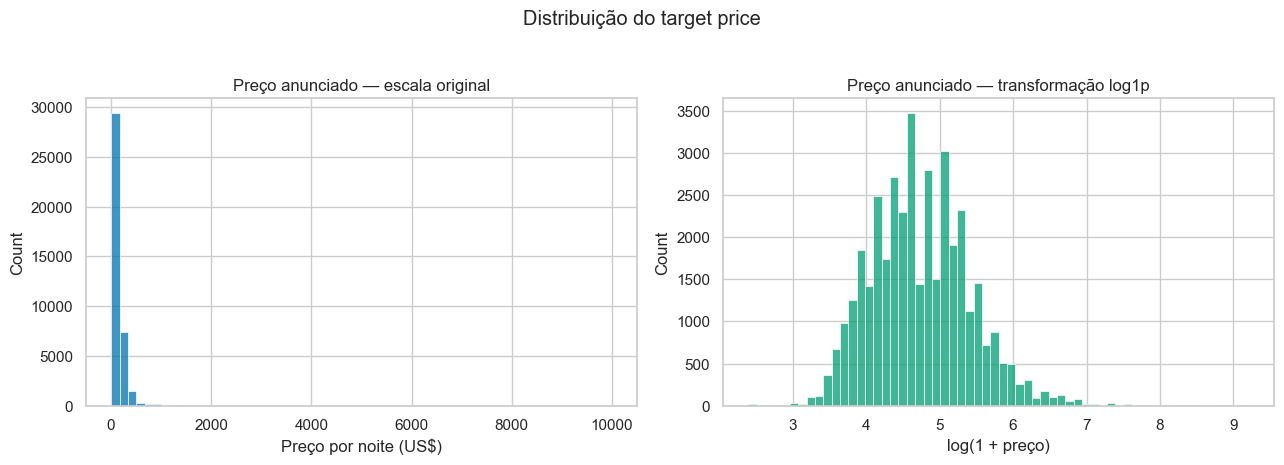

In [9]:
# Figura numérica 1 — distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train_df["price"], bins=60, ax=axes[0], color="#0072B2")
axes[0].set(title="Preço anunciado — escala original", xlabel="Preço por noite (US$)")
sns.histplot(np.log1p(train_df["price"]), bins=60, ax=axes[1], color="#009E73")
axes[1].set(title="Preço anunciado — transformação log1p", xlabel="log(1 + preço)")
fig.suptitle("Distribuição do target price", y=1.03)
plt.tight_layout()
plt.show()

- **Observação:** `price` tem mediana de US$ 106, média próxima de
  US$ 153 e máximo de US$ 10.000. A escala original fica comprimida pela cauda;
  com `log1p`, a região central se torna visível.
- **Por que importa:** a média é puxada pelos poucos anúncios caros e não
  representa o mesmo “preço típico” que a mediana.
- **Hipótese para a APS2:** comparar um target em `log1p`, sempre convertendo
  previsões e métricas importantes de volta para dólares.
- **Limitação:** o gráfico descreve os preços anunciados; não revela por que
  certos anúncios são mais caros.

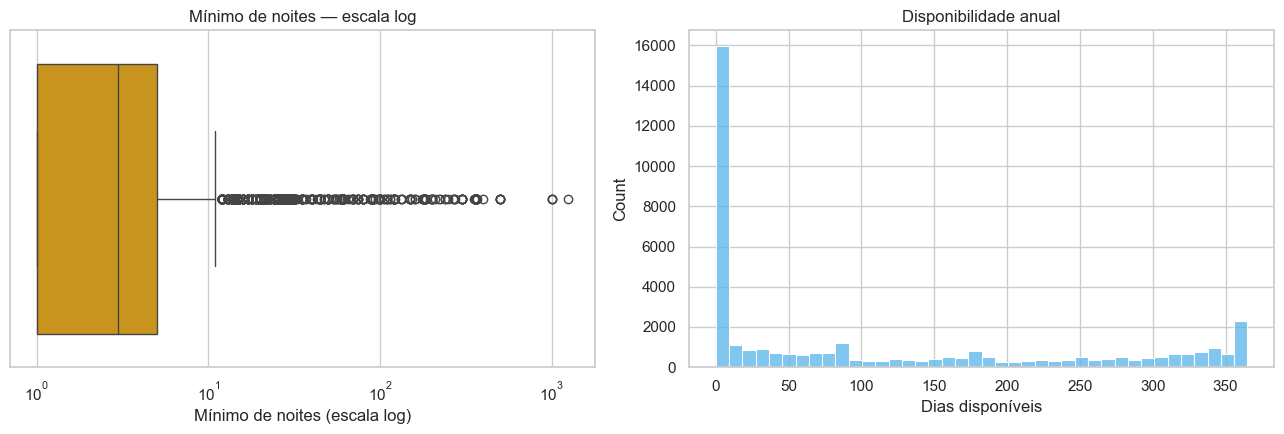

In [10]:
# Figuras numéricas 2 e 3
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=train_df["minimum_nights"], ax=axes[0], color="#E69F00")
axes[0].set(
    xscale="log",
    title="Mínimo de noites — escala log",
    xlabel="Mínimo de noites (escala log)",
)
sns.histplot(train_df["availability_365"], bins=40, ax=axes[1], color="#56B4E9")
axes[1].set(title="Disponibilidade anual", xlabel="Dias disponíveis")
plt.tight_layout()
plt.show()

- **Observação:** `minimum_nights` se concentra em valores baixos, mas chega
  a 1.250 noites. `availability_365` varia por todo o intervalo de zero a 365.
- **Por que importa:** as caudas podem afetar modelos sensíveis à escala.
- **Decisão:** manter os extremos por enquanto e avaliar transformações robustas
  na APS2. A escala log do boxplot muda apenas a visualização.
- **Limitação:** disponibilidade registrada não é o mesmo que ocupação ou
  demanda observada.

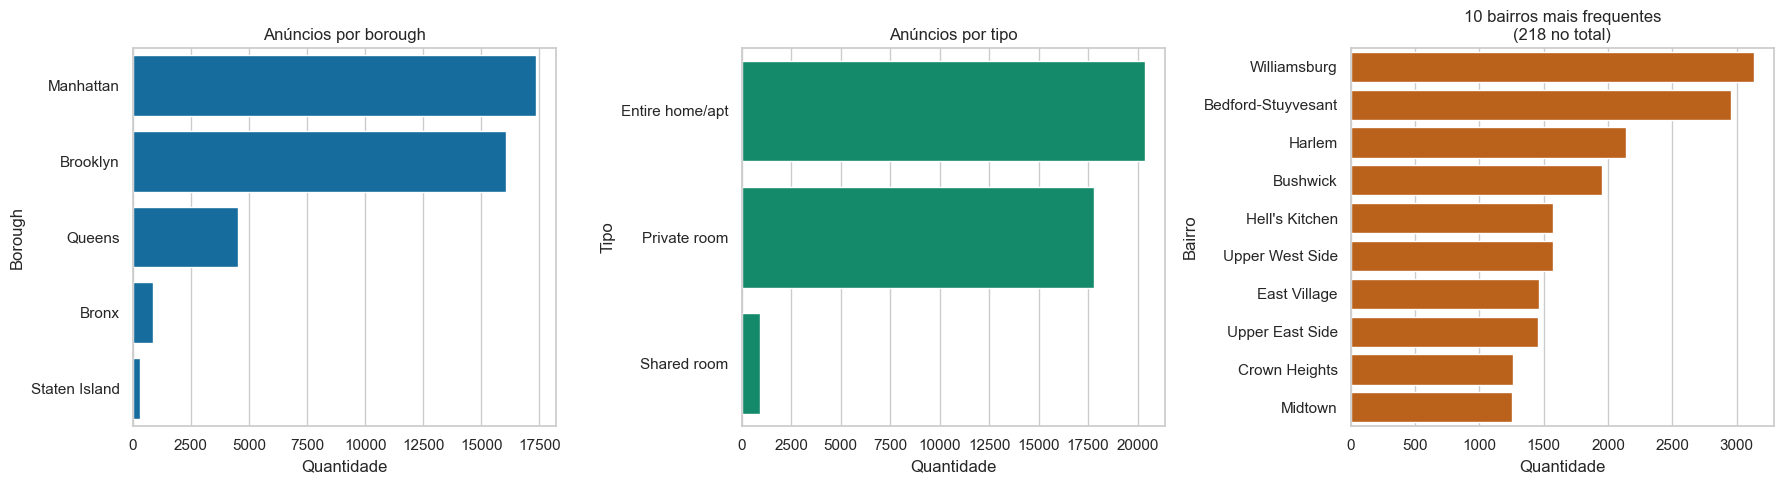

In [11]:
# Figuras categóricas 1, 2 e 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=train_df,
    y="neighbourhood_group",
    order=train_df["neighbourhood_group"].value_counts().index,
    ax=axes[0],
    color="#0072B2",
)
axes[0].set(title="Anúncios por borough", xlabel="Quantidade", ylabel="Borough")

sns.countplot(
    data=train_df,
    y="room_type",
    order=train_df["room_type"].value_counts().index,
    ax=axes[1],
    color="#009E73",
)
axes[1].set(title="Anúncios por tipo", xlabel="Quantidade", ylabel="Tipo")

top_neighbourhoods = train_df["neighbourhood"].value_counts().head(10).index
sns.countplot(
    data=train_df.loc[train_df["neighbourhood"].isin(top_neighbourhoods)],
    y="neighbourhood",
    order=top_neighbourhoods,
    ax=axes[2],
    color="#D55E00",
)
axes[2].set(
    title=f"10 bairros mais frequentes\n({train_df['neighbourhood'].nunique()} no total)",
    xlabel="Quantidade",
    ylabel="Bairro",
)
plt.tight_layout()
plt.show()

- **Observação:** Manhattan e Brooklyn concentram a maior parte dos anúncios;
  acomodações inteiras e quartos privados são muito mais frequentes que quartos
  compartilhados. Há 218 bairros no treino.
- **Por que importa:** grupos raros e alta cardinalidade podem dificultar a
  modelagem.
- **Decisão:** usar one-hot encoding com categorias desconhecidas ignoradas e
  monitorar bairros raros na APS2.
- **Limitação:** as contagens representam a composição deste dataset, não a
  distribuição de todas as hospedagens de Nova York.

## 7. Análise bivariada e multivariada

Depois de entender cada variável isoladamente, investigamos como elas se movem
em conjunto e como o target muda entre grupos.

Para ler cada figura, pergunte:

1. O que está nos eixos?
2. Qual padrão aparece?
3. Existem extremos ou grupos pequenos?
4. Que hipótese ou decisão de modelagem isso sugere?
5. O que o gráfico não permite concluir?

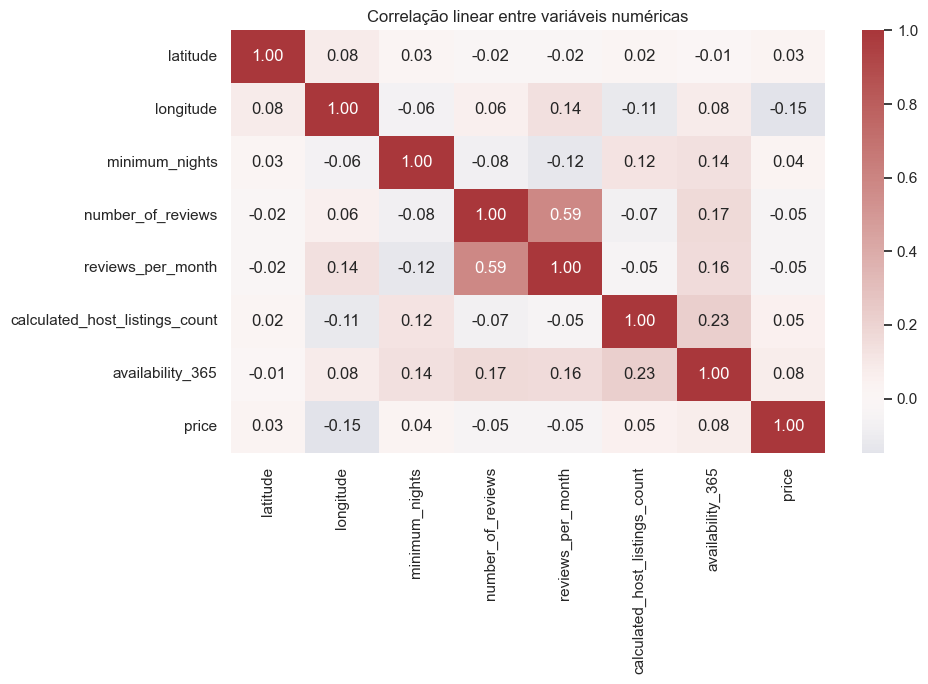

In [12]:
# Figura numérica-numérica 1 — correlações
variaveis_correlacao = [
    "latitude", "longitude", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "calculated_host_listings_count",
    "availability_365", "price",
]
matriz_correlacao = train_df[variaveis_correlacao].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matriz_correlacao, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlação linear entre variáveis numéricas")
plt.tight_layout()
plt.show()

- **Observação:** todas as correlações lineares isoladas com `price` são
  fracas; a maior em módulo é a de longitude, aproximadamente -0,15.
- **Por que importa:** uma correlação pequena elimina apenas uma relação linear
  forte, não relações curvas, locais ou dependentes de outras features.
- **Decisão:** preservar variáveis plausíveis e comparar modelos capazes de
  capturar não linearidades e interações na APS2.
- **Limitação:** correlação resume associação e não identifica causa e efeito.

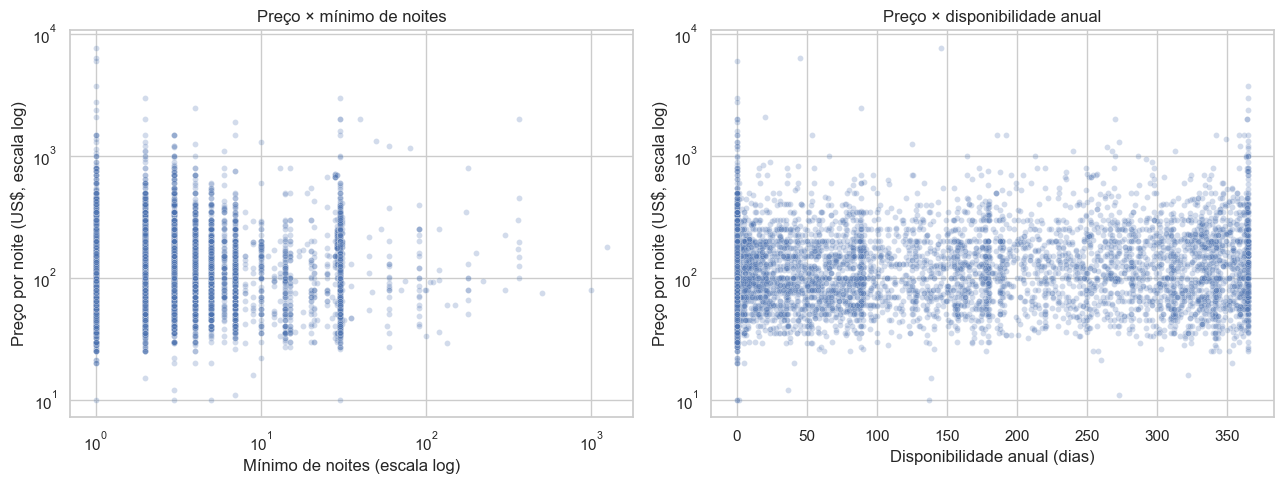

In [13]:
# Figuras numérica-numérica 2 e 3 — amostra apenas para legibilidade
amostra_para_grafico = train_df.sample(
    n=min(8_000, len(train_df)),
    random_state=RANDOM_STATE,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    data=amostra_para_grafico,
    x="minimum_nights",
    y="price",
    alpha=0.25,
    s=18,
    ax=axes[0],
)
axes[0].set(
    xscale="log",
    yscale="log",
    title="Preço × mínimo de noites",
    xlabel="Mínimo de noites (escala log)",
    ylabel="Preço por noite (US$, escala log)",
)

sns.scatterplot(
    data=amostra_para_grafico,
    x="availability_365",
    y="price",
    alpha=0.25,
    s=18,
    ax=axes[1],
)
axes[1].set(
    yscale="log",
    title="Preço × disponibilidade anual",
    xlabel="Disponibilidade anual (dias)",
    ylabel="Preço por noite (US$, escala log)",
)
plt.tight_layout()
plt.show()

- **Observação:** há forte sobreposição nos dois dispersogramas e nenhuma
  tendência linear simples entre preço, mínimo de noites e disponibilidade.
- **Por que importa:** uma única reta provavelmente não resume bem esses
  relacionamentos.
- **Hipótese para a APS2:** testar transformações ou modelos não lineares e
  verificar o ganho com validação.
- **Limitação:** os 8.000 pontos formam uma amostra apenas visual; o pipeline usa
  todos os registros do treino.

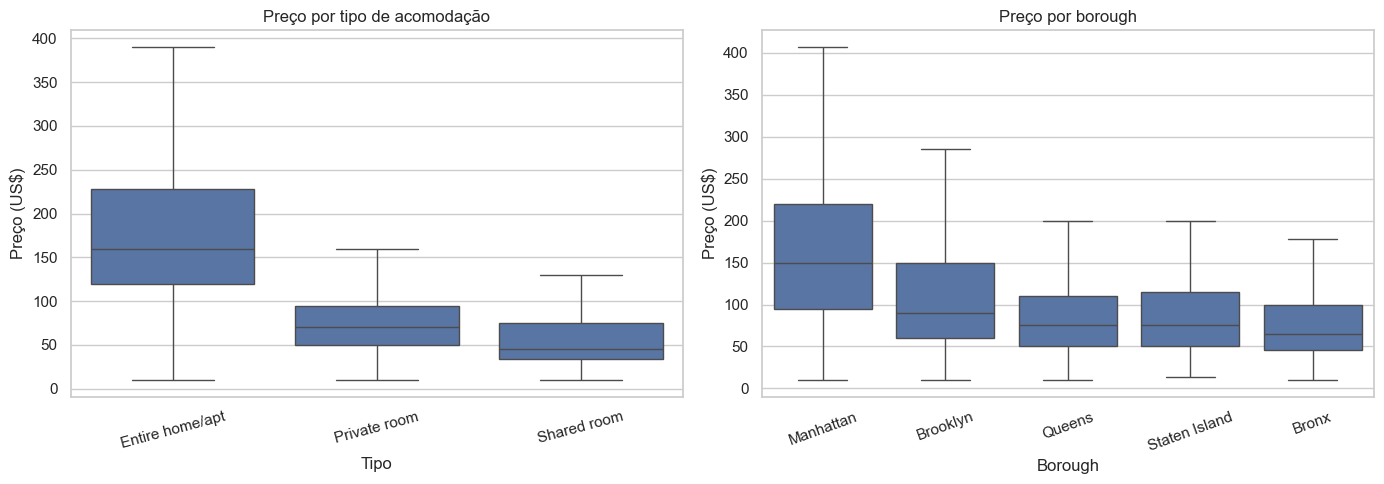

,count,median,mean
room_type,,,
Entire home/apt,20368,160.0,212.612480
Private room,17807,70.0,89.619532
Shared room,932,45.0,68.699571


,count,median,mean
neighbourhood_group,,,
Manhattan,17344,150.0,198.510032
Brooklyn,16059,90.0,123.809017
Queens,4546,75.0,98.520018
Staten Island,292,75.0,115.325342
Bronx,866,65.0,89.630485


In [14]:
# Figuras categórica-target 1 e 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_df, x="room_type", y="price", showfliers=False, ax=axes[0])
axes[0].set(title="Preço por tipo de acomodação", xlabel="Tipo", ylabel="Preço (US$)")
axes[0].tick_params(axis="x", rotation=15)

borough_order = (
    train_df.groupby("neighbourhood_group")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=train_df,
    x="neighbourhood_group",
    y="price",
    order=borough_order,
    showfliers=False,
    ax=axes[1],
)
axes[1].set(title="Preço por borough", xlabel="Borough", ylabel="Preço (US$)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(
    train_df.groupby("room_type")["price"].agg(["count", "median", "mean"])
)
display(
    train_df.groupby("neighbourhood_group")["price"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

- **Observação:** acomodações inteiras têm mediana de US$ 160; quartos
  privados, US$ 70; compartilhados, US$ 45. Manhattan apresenta mediana de
  US$ 150, contra US$ 90 no Brooklyn e US$ 65 no Bronx.
- **Por que importa:** tipo de acomodação e localização separam grupos com
  preços típicos bastante diferentes.
- **Decisão:** manter `room_type`, borough, bairro e coordenadas no baseline.
- **Limitação:** região e tipo também estão associados a tamanho, estrutura e
  outras características não observadas; o gráfico não isola seus efeitos.

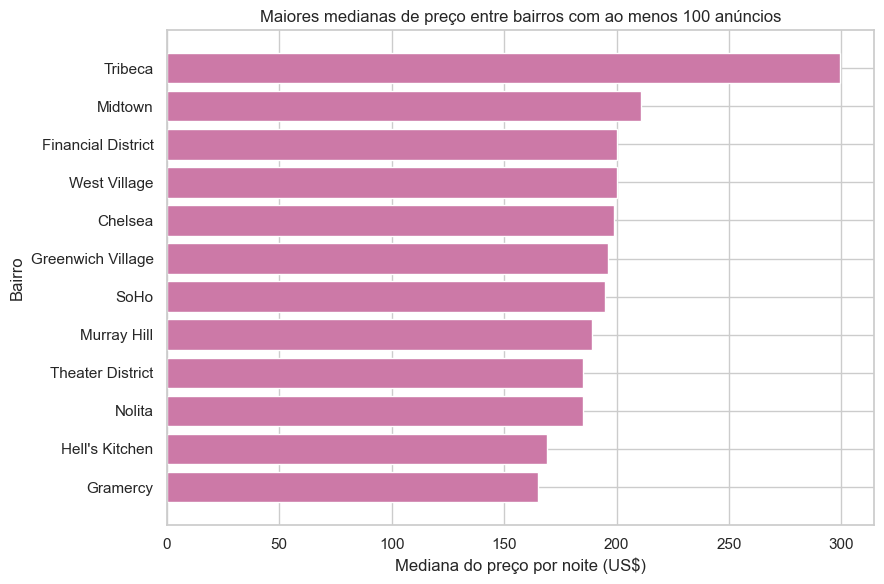

In [15]:
# Figura categórica-target 3 — bairros com suporte mínimo
resumo_bairros = (
    train_df.groupby("neighbourhood")["price"]
    .agg(count="size", median="median")
    .query("count >= 100")
    .nlargest(12, "median")
    .sort_values("median")
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(resumo_bairros.index, resumo_bairros["median"], color="#CC79A7")
ax.set(
    title="Maiores medianas de preço entre bairros com ao menos 100 anúncios",
    xlabel="Mediana do preço por noite (US$)",
    ylabel="Bairro",
)
plt.tight_layout()
plt.show()

- **Observação:** mesmo entre bairros com pelo menos 100 anúncios, as medianas
  variam bastante; Tribeca lidera o grupo exibido.
- **Por que importa:** bairro pode acrescentar informação além do borough.
- **Decisão:** manter `neighbourhood` inicialmente. O corte de 100 serve apenas
  para evitar conclusões visuais baseadas em grupos muito pequenos.
- **Limitação:** o bairro reúne diversas características não observadas e possui
  alta cardinalidade.

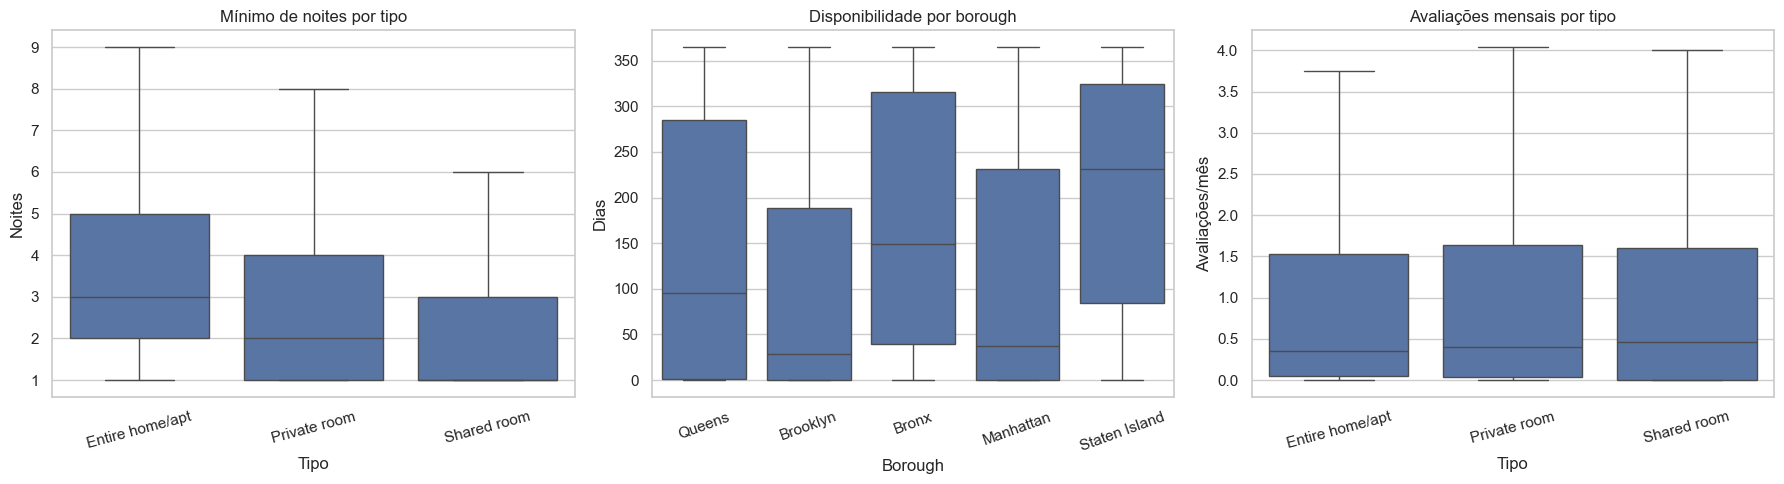

In [16]:
# Figuras numérica-categórica 1, 2 e 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(
    data=train_df,
    x="room_type",
    y="minimum_nights",
    showfliers=False,
    ax=axes[0],
)
axes[0].set(title="Mínimo de noites por tipo", xlabel="Tipo", ylabel="Noites")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=train_df,
    x="neighbourhood_group",
    y="availability_365",
    showfliers=False,
    ax=axes[1],
)
axes[1].set(title="Disponibilidade por borough", xlabel="Borough", ylabel="Dias")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=train_df,
    x="room_type",
    y="reviews_per_month",
    showfliers=False,
    ax=axes[2],
)
axes[2].set(title="Avaliações mensais por tipo", xlabel="Tipo", ylabel="Avaliações/mês")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

- **Observação:** mínimo de noites e avaliações mensais variam entre tipos de
  acomodação; a disponibilidade também difere entre boroughs.
- **Por que importa:** o efeito de uma variável pode depender de outra.
- **Hipótese para a APS2:** comparar modelos que consigam representar interações.
- **Limitação:** os boxplots escondem pontos extremos para leitura, mas nenhuma
  linha foi removida da base usada no pipeline.

## 8. Pipeline de pré-processamento

O pipeline funciona como uma receita que será aprendida **somente com o treino**:

```text
numéricas   → preencher pela mediana → padronizar
categóricas → preencher pela moda    → one-hot encoding
```

`fit_transform(X_train)` aprende as medianas, médias, desvios e categorias.
`transform(X_test)` reutiliza exatamente essas decisões, sem olhar o teste para
recalculá-las. A categoria artificial abaixo confirma que um valor novo não
quebra o encoder.

In [17]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews",
]

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

preprocessing_pipeline = Pipeline([
    ("preprocessor", preprocessor),
])

# Somente esta linha aprende parâmetros, usando apenas o treino.
features_treino_transformadas = preprocessing_pipeline.fit_transform(X_train)

# O teste reutiliza o pipeline já ajustado.
features_teste_transformadas = preprocessing_pipeline.transform(X_test)

# Simulamos uma categoria que nunca apareceu no treino.
exemplo_categoria_nova = X_test.iloc[[0]].copy()
exemplo_categoria_nova.loc[:, "room_type"] = "Tipo não observado no treino"
categoria_nova_transformada = preprocessing_pipeline.transform(
    exemplo_categoria_nova
)

nomes_das_features = preprocessing_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

numero_features_transformadas = features_treino_transformadas.shape[1]

assert numero_features_transformadas == features_teste_transformadas.shape[1]
assert numero_features_transformadas == categoria_nova_transformada.shape[1]
assert numero_features_transformadas == len(nomes_das_features)

print(
    "Features originais selecionadas:",
    len(numeric_features) + len(categorical_features),
)
print(f"Features após transformação: {numero_features_transformadas}")
print(f"Treino transformado: {features_treino_transformadas.shape}")
print(f"Teste transformado: {features_teste_transformadas.shape}")
print("Categoria inédita transformada sem novo ajuste: OK")

Features originais selecionadas: 11
Features após transformação: 234
Treino transformado: (39107, 234)
Teste transformado: (9777, 234)
Categoria inédita transformada sem novo ajuste: OK


### Decisões para o baseline

- **Entram:** localização, mínimo de noites, atividade de avaliações,
  disponibilidade, escala do anfitrião e tipo de acomodação.
- **Ficam fora:** IDs, nomes e a data bruta, pois não possuem interpretação
  numérica direta ou têm alta cardinalidade sem tratamento específico.
- **Redundância possível:** bairro, borough e coordenadas descrevem localização
  em granularidades diferentes. Mantê-los é uma hipótese inicial, que deverá ser
  comparada na APS2.
- **Garantia contra vazamento:** nenhum método `fit` é chamado com `X_test`.

## 9. PCA das variáveis numéricas

### Intuição antes da fórmula

O PCA cria novos eixos combinando as variáveis originais:

- **PC1** é a direção que preserva a maior variação possível;
- **PC2** preserva a maior parte restante e é perpendicular a PC1;
- os **loadings** mostram quais variáveis pesam mais em cada componente.

Como dias, coordenadas e contagens têm escalas diferentes, primeiro imputamos e
padronizamos usando apenas `X_train`. O PCA serve para visualizar uma versão
bidimensional dos dados; ele não prevê `price`, não procura causas e não garante
separação entre grupos.

Variância explicada: [0.246 0.191]


,PC1,PC2
latitude,-0.018709,0.018113
longitude,0.236467,-0.147050
minimum_nights,-0.164955,0.494640
number_of_reviews,0.638690,0.025050
reviews_per_month,0.655551,-0.000899
calculated_host_listings_count,-0.090484,0.618643
availability_365,0.265827,0.591635


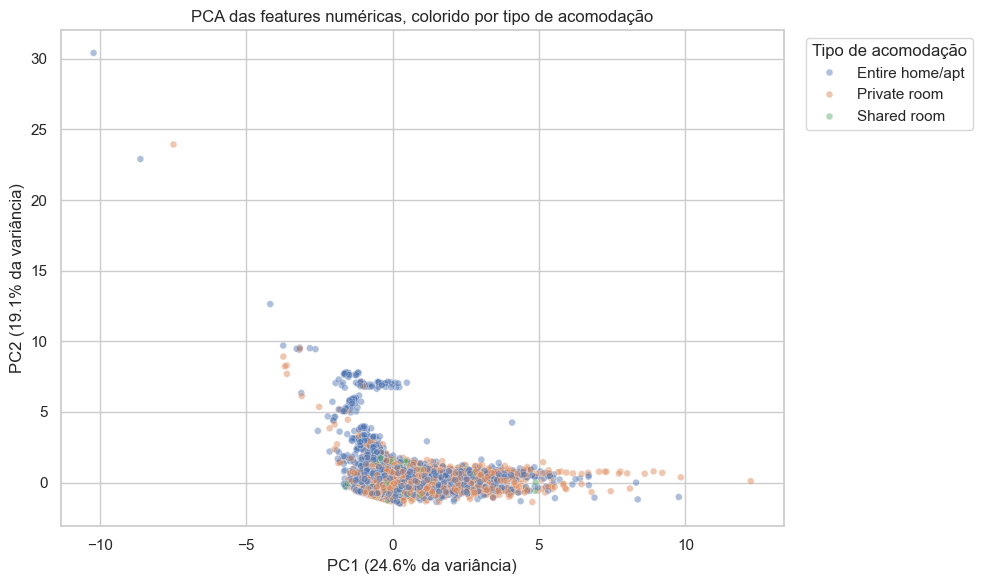

In [18]:
pca_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

preparo_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

features_numericas_padronizadas = preparo_pca.fit_transform(
    X_train[pca_features]
)

pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(features_numericas_padronizadas)

dados_pca = pd.DataFrame(
    componentes_pca,
    columns=["PC1", "PC2"],
    index=X_train.index,
).join(X_train[["room_type", "neighbourhood_group"]])

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=["PC1", "PC2"],
)

print("Variância explicada:", pca.explained_variance_ratio_.round(3))
display(loadings.style.background_gradient(cmap="vlag", axis=None))

amostra_pca = dados_pca.sample(
    n=min(10_000, len(dados_pca)),
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=amostra_pca,
    x="PC1",
    y="PC2",
    hue="room_type",
    alpha=0.45,
    s=24,
    ax=ax,
)
ax.set(
    title="PCA das features numéricas, colorido por tipo de acomodação",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)",
)
ax.legend(
    title="Tipo de acomodação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

- **Observação:** PC1 explica 24,6% da variância e recebe maior peso de
  `number_of_reviews` e `reviews_per_month`. PC2 explica 19,1% e recebe maior
  peso de disponibilidade, escala do anfitrião e mínimo de noites.
- **Interpretação:** PC1 resume principalmente atividade de avaliações; PC2,
  características de disponibilidade e operação. Juntos, preservam 43,8% da
  variação numérica, portanto a projeção é um resumo parcial.
- **Resultado visual:** os tipos de acomodação se sobrepõem nos dois componentes;
  não existe separação clara.
- **Limitação:** PCA maximiza variância das features, não capacidade de prever
  preço. A ausência de separação no gráfico não torna `room_type` inútil.

## 10. Síntese final

- **Distribuição do target:** no treino, `price` tem mediana de US$ 106,
  média de aproximadamente US$ 153 e máximo de US$ 10.000. A forte assimetria
  à direita torna `log1p(price)` uma hipótese para a APS2, com avaliação
  final também na escala original de dólares.
- **Localização e acomodação:** as medianas são maiores em acomodações inteiras
  (US$ 160) e em Manhattan (US$ 150). Quartos privados e compartilhados têm
  medianas de US$ 70 e US$ 45; Brooklyn tem US$ 90 e Bronx, US$ 65.
- **Qualidade:** não há duplicatas completas nem IDs duplicados. Há 11 preços
  não positivos, removidos como targets inválidos. Os 14 casos com
  `minimum_nights > 365` e os preços altos foram mantidos por falta de
  evidência de erro.
- **Ausências:** `last_review` e `reviews_per_month` têm 10.052
  ausências, todas associadas a anúncios sem avaliações. Nesses casos,
  `reviews_per_month` foi preenchida com zero e `has_reviews`
  registra explicitamente essa condição.
- **PCA:** os dois primeiros componentes explicam cerca de 43,8% da variância
  das features numéricas padronizadas (24,6% e 19,1%). PC1 é mais associado à
  atividade de avaliações; PC2, à disponibilidade, escala do anfitrião e mínimo
  de noites. A projeção não forma grupos claramente separados por tipo de
  acomodação, portanto não prova capacidade preditiva de `price`.
- **Pipeline da APS2:** entram oito features numéricas e três categóricas. IDs,
  nomes e a data bruta ficam fora do baseline. O pipeline aprende imputação,
  escala e categorias apenas no treino e transforma o teste, inclusive com
  categoria inédita, sem novo `fit`.

## Limitações

Os dados representam anúncios de 2019. Preço anunciado não equivale a preço
pago, ocupação, demanda ou receita. O conjunto não contém características
detalhadas do imóvel nem confirma a veracidade de todos os extremos. As
associações observadas não permitem afirmar causalidade nem descrever o mercado
atual de Nova York.

## Referências

- [New York City Airbnb Open Data — Kaggle](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)
- [Inside Airbnb](https://insideairbnb.com/get-the-data/)
- [Scikit-learn — ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)
- [Scikit-learn — PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)